# Figure 1 — Temporal framing of social-exclusion rules

Per-rule annotations produced by
`scripts/classifiers/classify_work_polity.py`:

- **`rule_time_reference`** ∈ {contemporary, past, future, mixed, timeless}
- **`rule_polity`** — short canonical polity label

**Panel A** — author × time-reference, stacked 100 % bars ordered by floruit.
**Panel B** — top polities, colored by dominant time reference.

Styled for a two-column magazine figure (≈ 18 cm wide, Arial/Helvetica,
7–8 pt, 300 dpi PNG + editable-text PDF).


In [1]:
import pathlib
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams

# Science-magazine-friendly defaults
rcParams["font.family"] = ["Helvetica", "Arial", "sans-serif"]
rcParams["font.size"] = 7
rcParams["axes.labelsize"] = 8
rcParams["axes.titlesize"] = 9
rcParams["axes.titleweight"] = "bold"
rcParams["axes.linewidth"] = 0.6
rcParams["xtick.labelsize"] = 7
rcParams["ytick.labelsize"] = 7
rcParams["xtick.major.width"] = 0.6
rcParams["ytick.major.width"] = 0.6
rcParams["xtick.major.size"] = 2.5
rcParams["ytick.major.size"] = 2.5
rcParams["legend.fontsize"] = 7
rcParams["legend.frameon"] = False
rcParams["pdf.fonttype"] = 42    # editable text in PDF
rcParams["ps.fonttype"] = 42

REPO = pathlib.Path().resolve().parent
DATA = REPO / "data" / "processed_data" / "rules_full_dataset.tsv"
FIGDIR = REPO / "analysis_notebooks" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA, sep="\t")
print(
    f"{len(df):,} rules / {df['author'].nunique()} authors / "
    f"{df['file_id'].nunique()} works"
)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/homebrew/Cellar/python@3.10/3.10.13_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/homebrew/Cellar/python@3.10/3.10.13_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/opt/homebrew/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/homebrew/lib/python3.

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/homebrew/Cellar/python@3.10/3.10.13_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/homebrew/Cellar/python@3.10/3.10.13_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/opt/homebrew/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/homebrew/lib/python3.

AttributeError: _ARRAY_API not found

1,594 rules / 19 authors / 25 works


In [2]:
# Order authors by floruit year; compute time-reference proportions.
author_order = (
    df.groupby("author")
    .agg(floruit=("impact_year", "first"), n=("rule_uid", "count"))
    .reset_index()
    .sort_values("floruit")
    .reset_index(drop=True)
)
authors = author_order["author"].tolist()

time_levels = ["past", "contemporary", "mixed", "future", "timeless"]
colors = {
    "contemporary": "#2b6cb0",   # steel blue
    "past":         "#c05621",   # burnt orange
    "future":       "#2f855a",   # forest green
    "mixed":        "#805ad5",   # purple
    "timeless":     "#a0aec0",   # neutral gray
}

counts = (
    df.groupby(["author", "rule_time_reference"])
    .size()
    .unstack(fill_value=0)
    .reindex(authors)
)
for t in time_levels:
    if t not in counts.columns:
        counts[t] = 0
counts = counts[time_levels]
props = counts.div(counts.sum(axis=1), axis=0)
props


rule_time_reference,past,contemporary,mixed,future,timeless
author,,,,,
Andocides,0.000000,1.000000,0.000000,0.000000,0.000000
Antiphon,0.000000,1.000000,0.000000,0.000000,0.000000
Hippocrates,0.013793,0.137931,0.000000,0.000000,0.848276
Aristophanes,0.000000,1.000000,0.000000,0.000000,0.000000
Lysias,0.000000,1.000000,0.000000,0.000000,0.000000
Isocrates,0.021277,0.872340,0.000000,0.000000,0.106383
Isaeus,0.000000,1.000000,0.000000,0.000000,0.000000
Hyperides,0.000000,1.000000,0.000000,0.000000,0.000000
Aeschines,0.021277,0.978723,0.000000,0.000000,0.000000


In [3]:
# Panel B data: top polities + dominant time reference per polity.
TOP_N = 10
polities = df["rule_polity"].value_counts().head(TOP_N)
dom = (
    df.groupby("rule_polity")["rule_time_reference"]
    .agg(lambda s: s.value_counts().idxmax())
)
polity_colors = [colors[dom.loc[p]] for p in polities.index]

def _wrap(label, width=34):
    return label if len(label) <= width else label[: width - 1] + "…"

polity_labels = [_wrap(p) for p in polities.index]
polities


rule_polity
Classical Athens                              457
Generic / abstract (no specific polity)       398
Early Christian communities (Roman Empire)    139
Classical Greek city-states                   137
Classical Greece                               63
Early Christian communities                    38
Roman Empire                                   36
Classical Greek city-states (idealized)        31
Mythological / legendary setting               19
Roman Empire (Greek East)                      19
Name: count, dtype: int64

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


Saved /Users/charlesdedampierre/Desktop/Rsearch Folder/Human Rights/analysis_notebooks/figures/fig1_polity_time.png


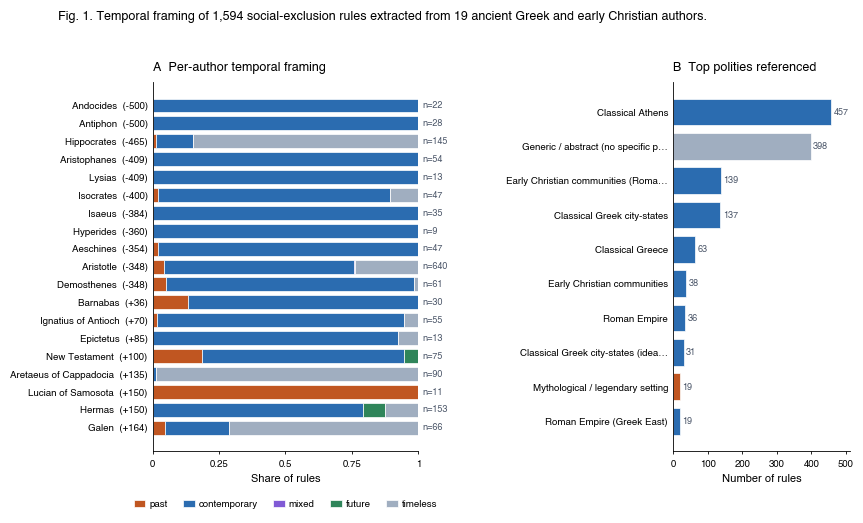

In [4]:
fig, (axA, axB) = plt.subplots(
    1, 2, figsize=(9.0, 4.8),
    gridspec_kw={"width_ratios": [1.5, 1.0], "wspace": 1.15},
)

# --- Panel A: author x time-reference stacked bar --------------------
y = range(len(authors))
left = [0.0] * len(authors)
for t in time_levels:
    vals = props[t].values
    axA.barh(
        list(y), vals, left=left,
        color=colors[t], label=t,
        height=0.78, edgecolor="white", linewidth=0.5,
    )
    left = [l + v for l, v in zip(left, vals)]

labels = [
    f"{a}  ({int(f):+d})"
    for a, f in zip(authors, author_order["floruit"].astype(int))
]
axA.set_yticks(list(y))
axA.set_yticklabels(labels)
axA.invert_yaxis()
axA.set_xlim(0, 1)
axA.set_xticks([0, 0.25, 0.5, 0.75, 1])
axA.set_xticklabels(["0", "0.25", "0.5", "0.75", "1"])
axA.set_xlabel("Share of rules")
axA.set_title("A  Per-author temporal framing",
              loc="left", fontsize=9, pad=8, fontweight="bold")
axA.spines[["top", "right"]].set_visible(False)
axA.tick_params(axis="y", length=0)

# Annotate n on the right of each bar
for yi, n in enumerate(author_order["n"].values):
    axA.text(
        1.015, yi, f"n={int(n)}",
        va="center", ha="left", fontsize=6.5, color="#4a5568",
    )

# Legend above plot
axA.legend(
    loc="lower center", bbox_to_anchor=(0.5, -0.18),
    ncol=5, handlelength=1.2, columnspacing=1.6, handletextpad=0.4,
)

# --- Panel B: top polities -------------------------------------------
yB = range(len(polities))
axB.barh(
    list(yB), polities.values,
    color=polity_colors, edgecolor="white", linewidth=0.5, height=0.78,
)
axB.set_yticks(list(yB))
axB.set_yticklabels(polity_labels)
axB.invert_yaxis()
axB.set_xlabel("Number of rules")
axB.set_title("B  Top polities referenced",
              loc="left", fontsize=9, pad=8, fontweight="bold")
axB.spines[["top", "right"]].set_visible(False)
axB.tick_params(axis="y", length=0)

# Value annotations
xmax = polities.max()
axB.set_xlim(0, xmax * 1.12)
for yi, v in enumerate(polities.values):
    axB.text(
        v + xmax * 0.015, yi, f"{int(v)}",
        va="center", ha="left", fontsize=6.5, color="#4a5568",
    )

fig.suptitle(
    "Fig. 1. Temporal framing of 1,594 social-exclusion rules "
    "extracted from 19 ancient Greek and early Christian authors.",
    fontsize=9, y=1.03, x=0.02, ha="left", fontweight="bold",
)

for ext in ("png", "pdf"):
    fig.savefig(
        FIGDIR / f"fig1_polity_time.{ext}",
        dpi=300, bbox_inches="tight",
    )
print("Saved", FIGDIR / "fig1_polity_time.png")
plt.show()


In [5]:
# Quick numeric summary to accompany the figure
print("Time-reference distribution (all rules):")
print(df["rule_time_reference"].value_counts().to_string())
print()
print("Rules per author, with dominant time reference:")
dom_auth = (
    df.groupby("author")["rule_time_reference"]
    .agg(["count", lambda s: s.value_counts().idxmax()])
    .rename(columns={"<lambda_0>": "dominant"})
    .sort_values("count", ascending=False)
)
print(dom_auth.to_string())


Time-reference distribution (all rules):
rule_time_reference
contemporary    1067
timeless         441
past              68
future            17
mixed              1

Rules per author, with dominant time reference:
                        count      dominant
author                                     
Aristotle                 640  contemporary
Hermas                    153  contemporary
Hippocrates               145      timeless
Aretaeus of Cappadocia     90      timeless
New Testament              75  contemporary
Galen                      66      timeless
Demosthenes                61  contemporary
Ignatius of Antioch        55  contemporary
Aristophanes               54  contemporary
Isocrates                  47  contemporary
Aeschines                  47  contemporary
Isaeus                     35  contemporary
Barnabas                   30  contemporary
Antiphon                   28  contemporary
Andocides                  22  contemporary
Epictetus                  13  contem